# Modeling and External Evaluation

Batch 1에서만 split, CV, 전처리 학습과 hyperparameter tuning을 수행한다. 타깃은 `log(cycle_life)`로 학습하고 MAPE는 cycle 단위로 역변환해 계산한다.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RESULTS = ROOT / 'results'


## Model comparison

In [2]:
comparison = pd.read_csv(RESULTS/'tables/model_comparison.csv'); comparison

,model,cv_mape,cv_std,valid_mape,best_params
0,GradientBoosting,10.454488,2.572062,8.476181,"{""model__learning_rate"": 0.1, ""model__max_dept..."
1,ElasticNet,8.096499,2.208335,20.577426,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.1}"
2,LinearRegression,16.954565,2.945049,68.355808,{}


공식 제외 규칙 반영 후 ElasticNet은 CV 평균이 낮지만 unseen-policy hold-out에서 크게 악화됐다. 제한된 깊이의 Gradient Boosting이 hold-out 일반화와 비선형성 대응에서 우세해 최종 선택됐다.

## Performance

In [3]:
performance = pd.read_csv(RESULTS/'model_performance.csv'); performance

,set,mape_percent,note
0,Train (Batch 1 CV),10.454488,GradientBoosting
1,Valid (Batch 1 Hold-out),8.476181,GroupShuffleSplit by charging_policy
2,Test (Batch2),37.005556,external batch; no tuning
3,Test (Batch3),16.931176,external batch; no tuning
4,Gap Train-Valid,-1.978307,%p
5,Gap Valid-Test,28.529375,%p
6,Gap Target-Test,27.905556,%p vs paper target
7,Gap Batch2-Batch3,-20.074379,%p


## Batch 2 test and residuals

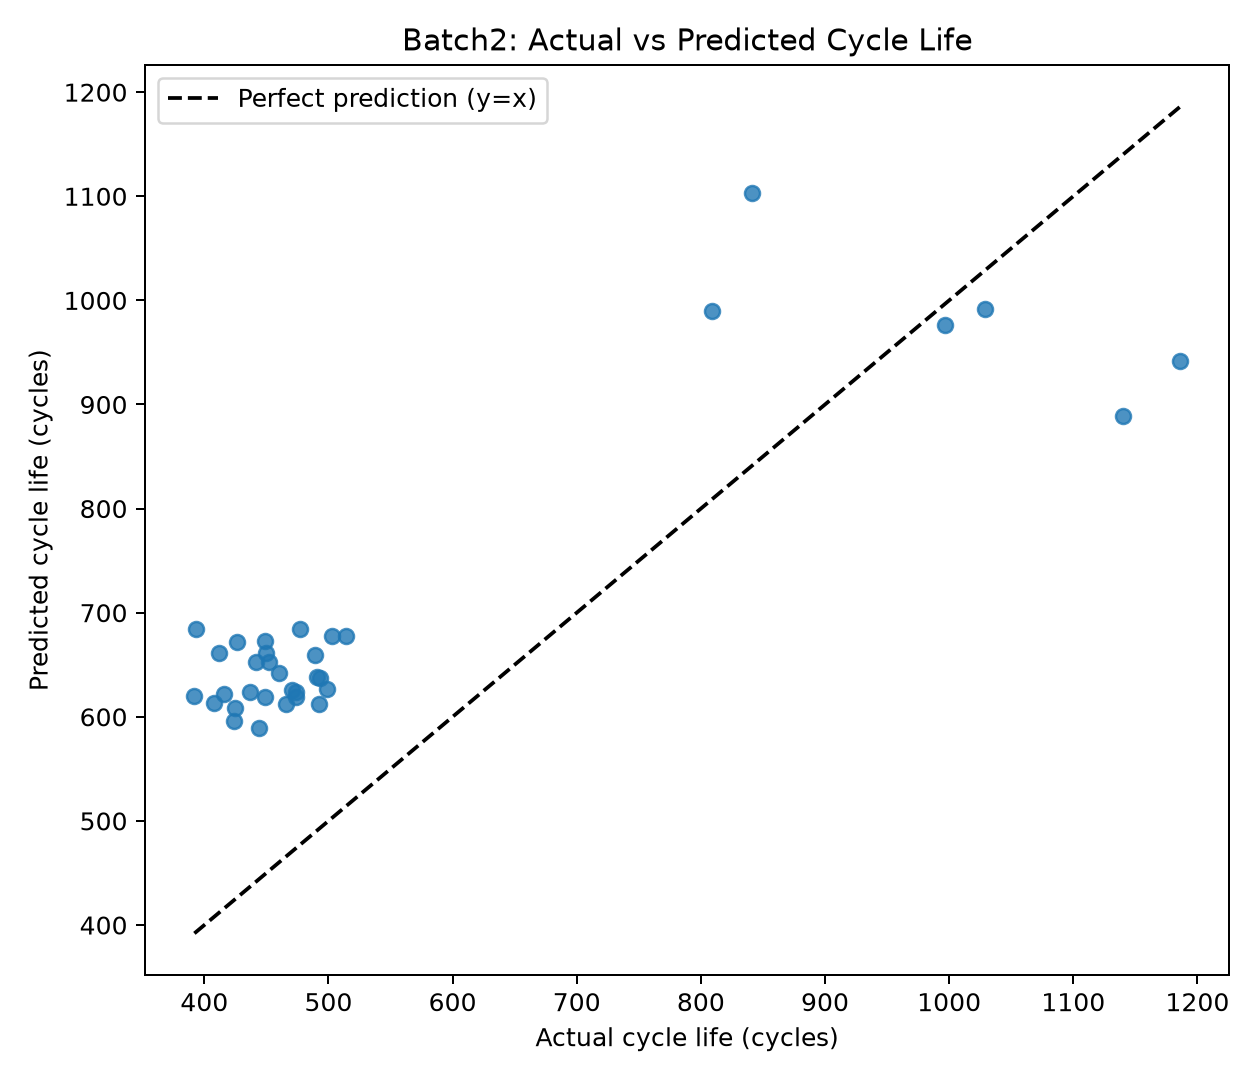

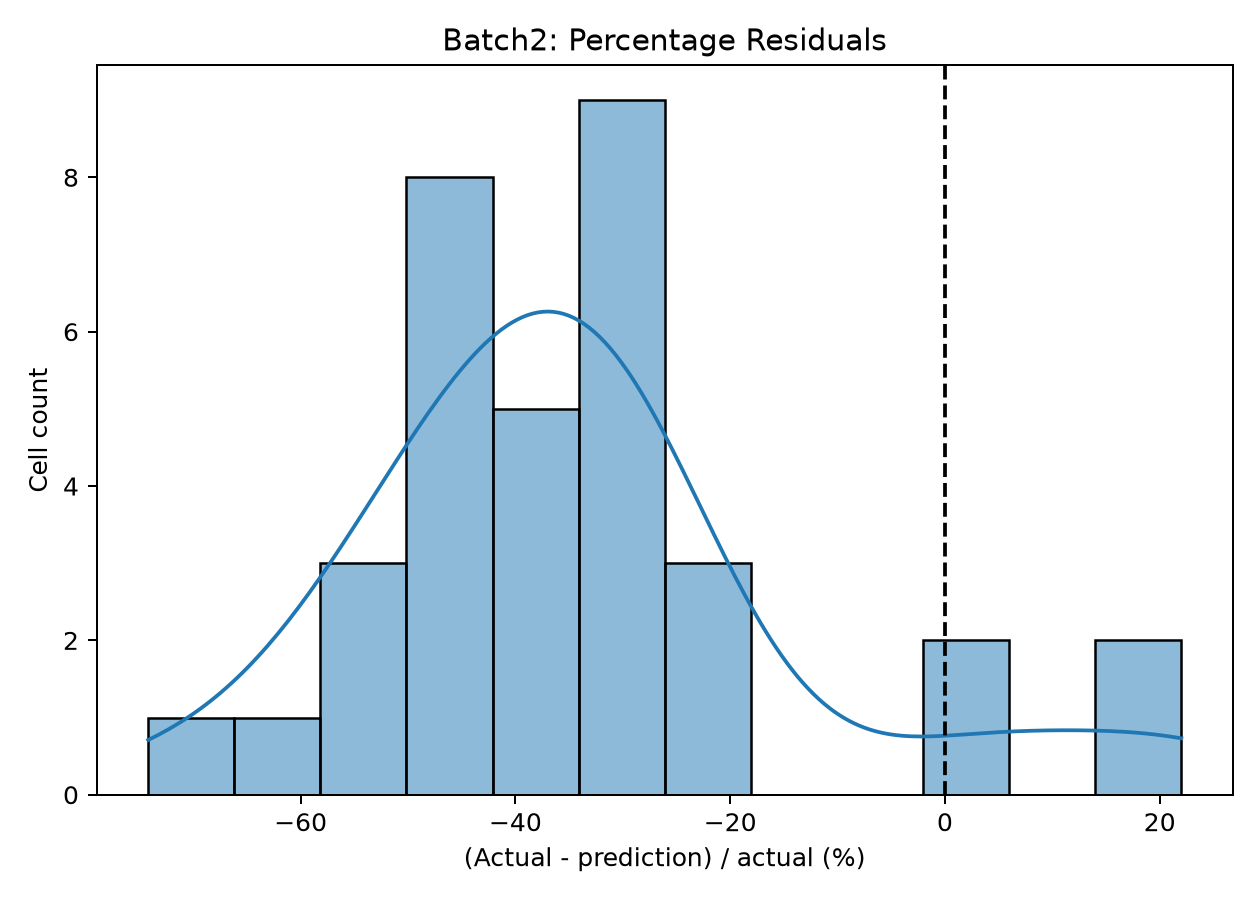

In [4]:
display(Image(filename=RESULTS/'figures/test_batch2_actual_vs_pred.png')); display(Image(filename=RESULTS/'figures/test_batch2_residual.png'))

## Batch 3 generalization

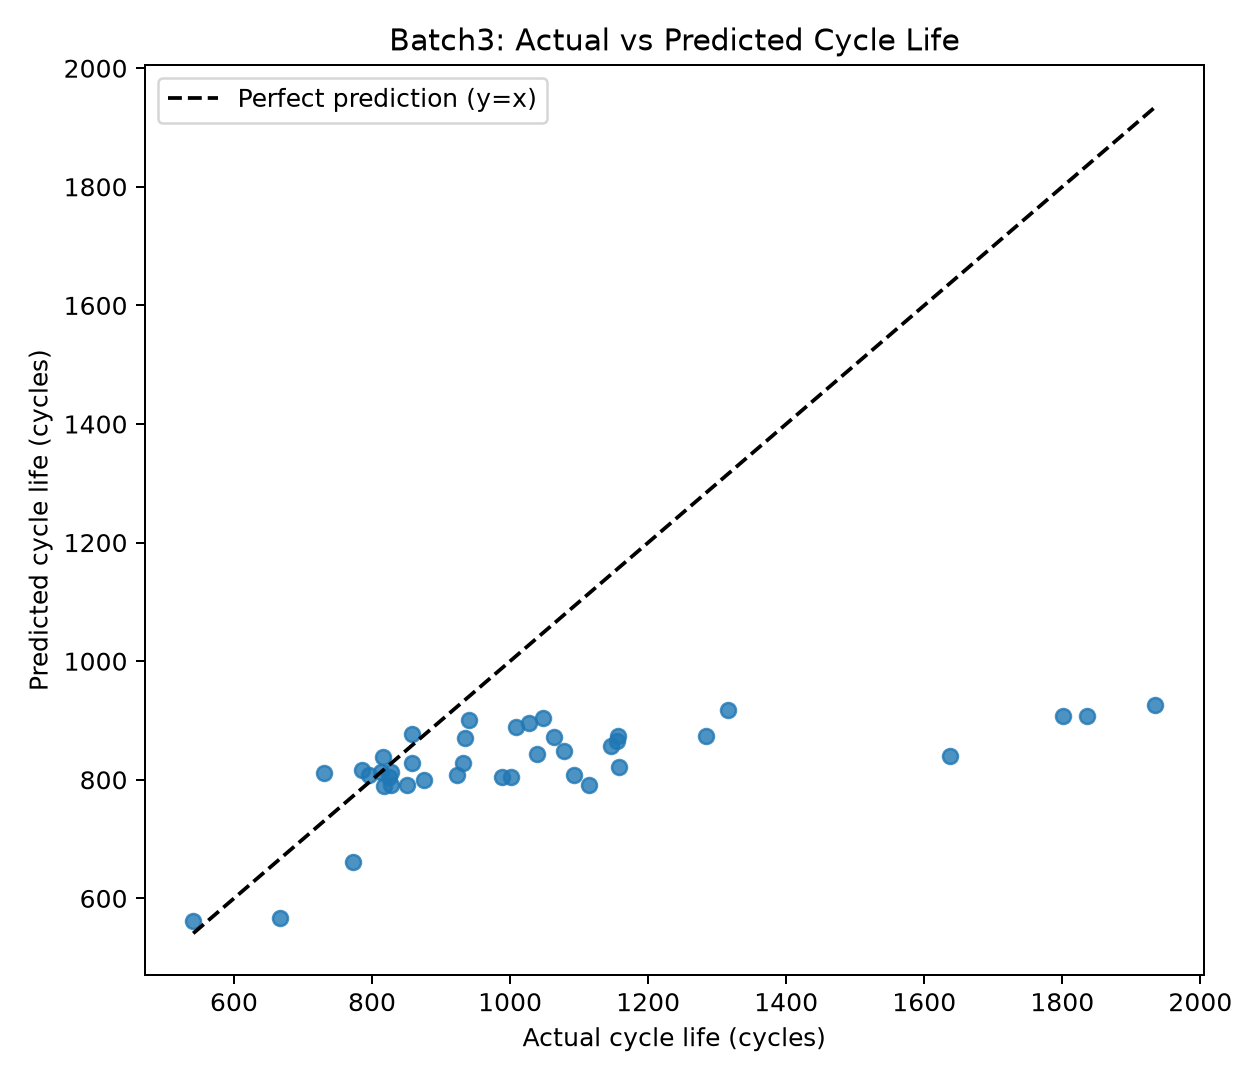

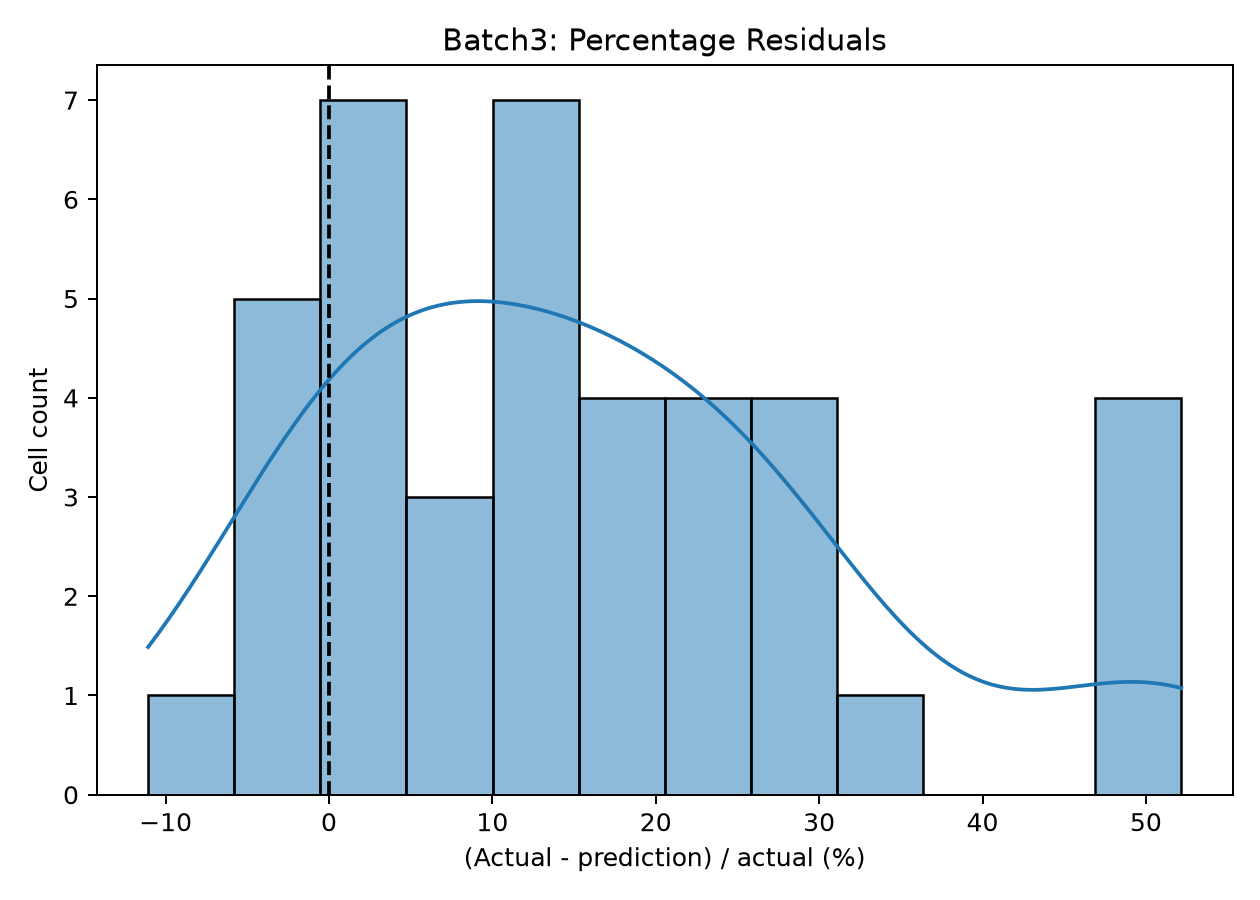

In [5]:
display(Image(filename=RESULTS/'figures/test_batch3_actual_vs_pred.png')); display(Image(filename=RESULTS/'figures/test_batch3_residual.png'))

## Error analysis

In [6]:
errors = pd.read_csv(RESULTS/'tables/error_analysis_batch2.csv'); errors[['cell_id','cycle_life','prediction','absolute_percentage_error','charging_policy','log_dq_var']].head(10)

,cell_id,cycle_life,prediction,absolute_percentage_error,charging_policy,log_dq_var
0,Batch2_cell_006,393.0,684.588197,74.195470,3.6C(9%)-5C,-3.530040
1,Batch2_cell_030,412.0,660.940602,60.422476,5.6C(26%)-4.5C,-3.185410
2,Batch2_cell_019,392.0,619.710469,58.089405,6C(60%)-3C,-3.291958
3,Batch2_cell_014,426.0,671.535529,57.637448,3.6C(30%)-6C,-3.118520
4,Batch2_cell_021,408.0,613.465015,50.359072,6C(60%)-3C,-3.326679
5,Batch2_cell_018,449.0,672.657380,49.812334,5.2C(50%)-4.25C,-3.707303
6,Batch2_cell_005,416.0,621.738189,49.456295,3.6C(30%)-6C,-3.085882
7,Batch2_cell_041,442.0,652.409833,47.604035,5.6C(26%)-4.5C,-3.172366
8,Batch2_cell_026,450.0,660.940602,46.875689,5.6C(26%)-4.5C,-3.222054
9,Batch2_cell_029,452.0,652.702076,44.403114,5.2C(58%)-4C,-3.508248


Batch 2의 큰 오류는 주로 실제 400–500 cycle대 셀을 과대예측한 경우다. 이는 Batch 1에 500 cycle 미만 표본이 없고 Batch 2의 단수명 비중이 76.5%인 외삽 문제와 연결된다.